In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path('../..').resolve()
if str(PROJECT_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / 'src'))
from paths import DATA_RAW_DIR

DATA_DIR = DATA_RAW_DIR
IMG_DIR = DATA_DIR / 'images'
STYLES_CSV = DATA_DIR / 'styles.csv'
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

pd.set_option('display.max_columns', None)
np.random.seed(42)


print('Data dir exists:', DATA_DIR.exists())
print('Image dir exists:', IMG_DIR.exists())
print('Styles CSV exists:', STYLES_CSV.exists())

Data dir exists: True
Image dir exists: True
Styles CSV exists: True


In [2]:
df = pd.read_csv(STYLES_CSV, on_bad_lines='skip')
print(f'Loaded {len(df):,} rows')
df.head()

Loaded 44,424 rows


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt


In [3]:
# Quick info
print('Columns:', df.columns.tolist())
print()
print('Missing values:')
print(df.isna().sum())
print()
print('Dtypes:')
print(df.dtypes)

Columns: ['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName']

Missing values:
id                      0
gender                  0
masterCategory          0
subCategory             0
articleType             0
baseColour             15
season                 21
year                    1
usage                 317
productDisplayName      7
dtype: int64

Dtypes:
id                      int64
gender                 object
masterCategory         object
subCategory            object
articleType            object
baseColour             object
season                 object
year                  float64
usage                  object
productDisplayName     object
dtype: object


In [4]:
df['image_path'] = df['id'].astype(str) + '.jpg'
df['full_path'] = df['image_path'].apply(lambda p: IMG_DIR / p)
df['exists'] = df['full_path'].apply(lambda p: p.exists())

print(f'Total rows:        {len(df):,}')
print(f'Images present:    {df.exists.sum():,}')
print(f'Images missing:    {(~df.exists).sum():,}')

df = df[df['exists']].drop(columns=['exists']).reset_index(drop=True)
print(f'After filtering:   {len(df):,}')

Total rows:        44,424
Images present:    44,419
Images missing:    5
After filtering:   44,419


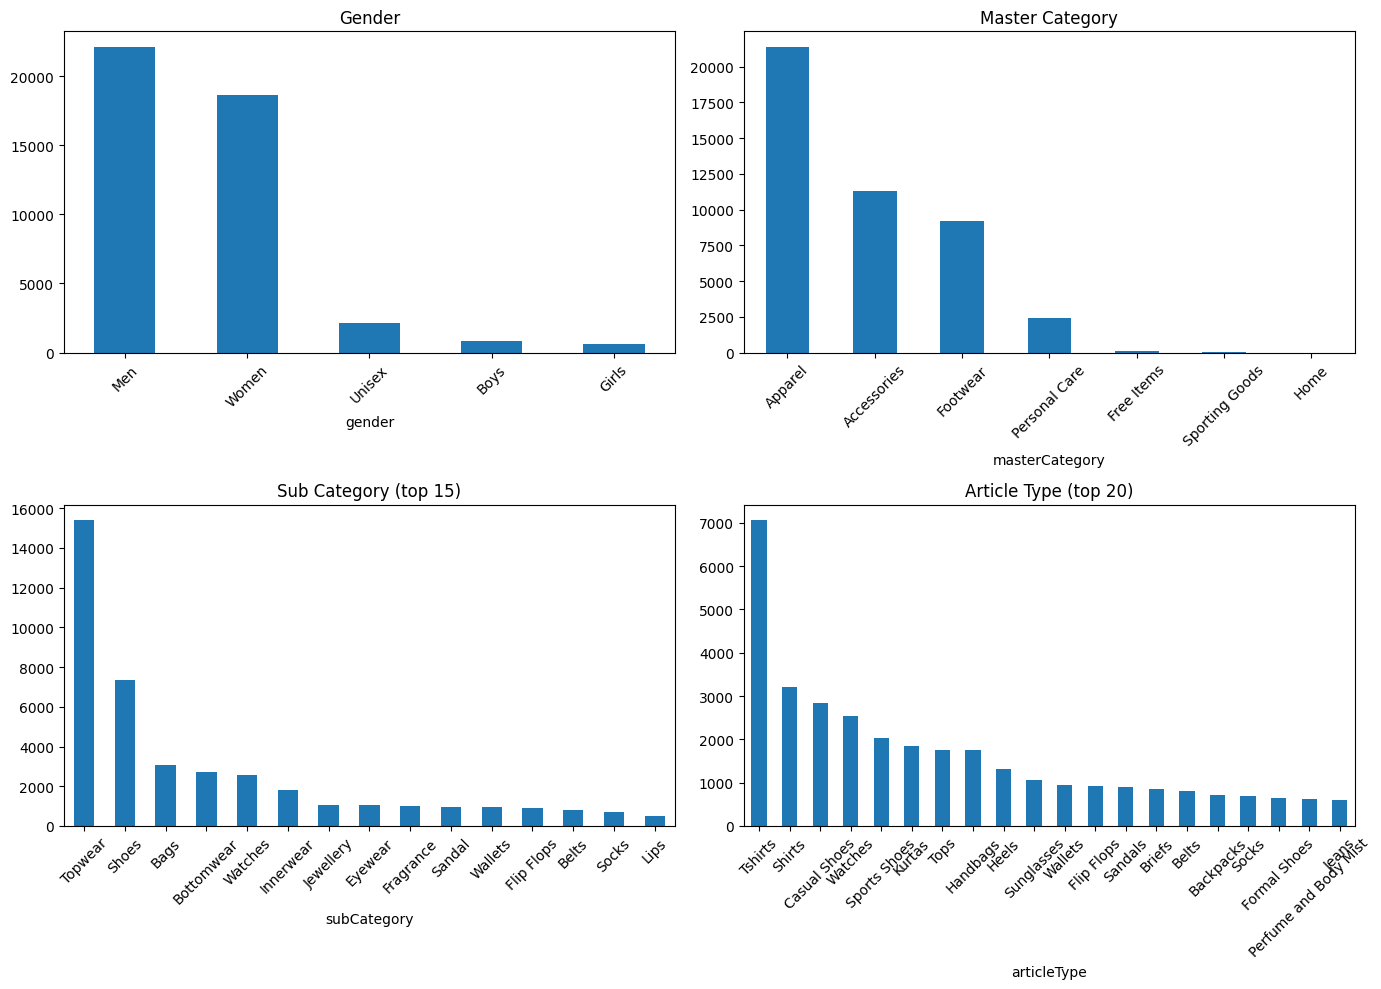

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

df['gender'].value_counts().plot(kind='bar', ax=axes[0, 0], title='Gender')
df['masterCategory'].value_counts().plot(kind='bar', ax=axes[0, 1], title='Master Category')
df['subCategory'].value_counts().head(15).plot(kind='bar', ax=axes[1, 0], title='Sub Category (top 15)')
df['articleType'].value_counts().head(20).plot(kind='bar', ax=axes[1, 1], title='Article Type (top 20)')

for ax in axes.flat:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [6]:
print('Distinct article types:', df['articleType'].nunique())
print('Distinct base colours:', df['baseColour'].nunique())
print('Distinct seasons:     ', df['season'].nunique())
print('Distinct usages:      ', df['usage'].nunique())

Distinct article types: 142
Distinct base colours: 46
Distinct seasons:      4
Distinct usages:       8


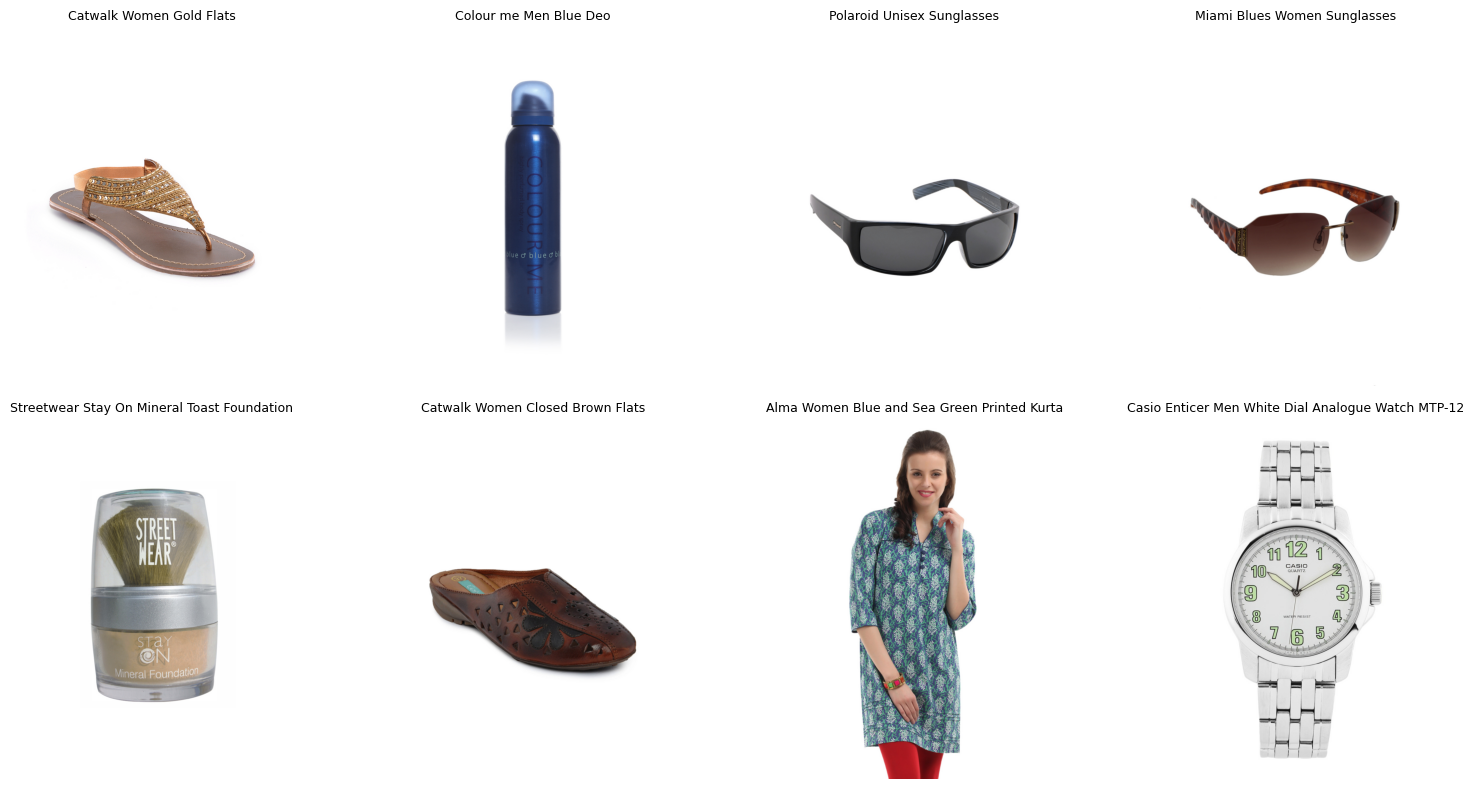

In [7]:
def show_samples(df, n=8):
    sample = df.sample(n, random_state=1)
    cols = 4
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
    for ax, (_, row) in zip(axes.flat, sample.iterrows()):
        img = Image.open(row['full_path'])
        ax.imshow(img)
        ax.set_title(str(row['productDisplayName'])[:50], fontsize=9)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

show_samples(df, n=8)

In [8]:
def build_caption(row):
    parts = []
    gender = str(row.get('gender', '')).strip()
    color = str(row.get('baseColour', '')).strip()
    article = str(row.get('articleType', '')).strip()
    usage = str(row.get('usage', '')).strip()
    season = str(row.get('season', '')).strip()
    name = str(row.get('productDisplayName', '')).strip()

    descriptor = ' '.join(p for p in [gender, color, article] if p and p.lower() != 'nan')
    if descriptor:
        parts.append(f'A {descriptor.lower()}')

    context = []
    if usage and usage.lower() != 'nan':
        context.append(f'for {usage.lower()} wear')
    if season and season.lower() != 'nan':
        context.append(f'in {season.lower()}')
    if context:
        parts.append(' '.join(context))

    caption = ', '.join(parts) + '.'
    if name and name.lower() != 'nan':
        caption += f' {name}.'
    return caption

df['caption'] = df.apply(build_caption, axis=1)

# Inspect
for caption in df['caption'].sample(10, random_state=2):
    print('-', caption)

- A men black watches, for casual wear in winter. Nautica Men Black Dial Watch.
- A girls pink tops, for casual wear in fall. Doodle Kids Girls Pink I love Shopping Top.
- A women white watches, for casual wear in winter. Fastrack Women White Dial Watch N6015SL01.
- A unisex yellow flip flops, for casual wear in summer. ADIDAS Unisex Adi Liner Yellow Flip Flop.
- A men teal kurtas, for ethnic wear in summer. Fabindia Men Teal Tussar Kurta.
- A men black belts, for casual wear in summer. Reid & Taylor Men Casual Black Belt.
- A boys black tshirts, for casual wear in summer. Avengers Boys Black Printed T-shirt.
- A women black dresses, for casual wear in summer. Flying Machine Women Cotton Black Dress.
- A men white tshirts, for casual wear in summer. Puma Men Dizzy Graphic White T-shirt.
- A men red shirts, for casual wear in fall. U.S. Polo Assn. Men Check Red Shirt.


count    44419.000000
mean        15.082082
std          1.625065
min          7.000000
25%         14.000000
50%         15.000000
75%         16.000000
max         24.000000
Name: caption_words, dtype: float64


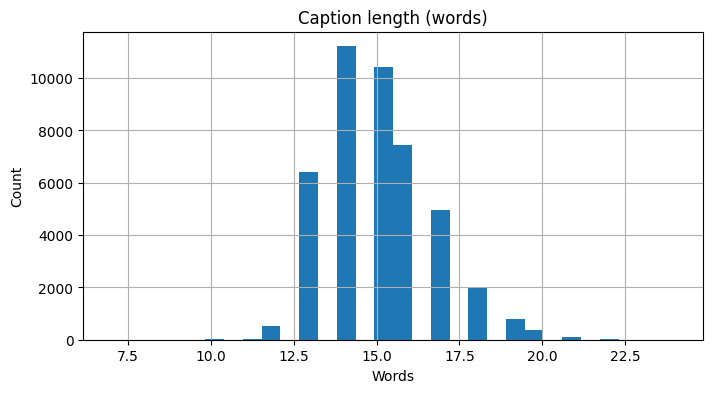

In [9]:
# Caption length stats (in words)
df['caption_words'] = df['caption'].str.split().str.len()
print(df['caption_words'].describe())

df['caption_words'].hist(bins=30, figsize=(8, 4))
plt.title('Caption length (words)')
plt.xlabel('Words')
plt.ylabel('Count')
plt.show()

In [10]:
from sklearn.model_selection import train_test_split

# Drop article types with too few samples (can't stratify)
type_counts = df['articleType'].value_counts()
valid_types = type_counts[type_counts >= 10].index
df = df[df['articleType'].isin(valid_types)].reset_index(drop=True)
print(f'After dropping rare classes: {len(df):,}')

train_df, temp_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['articleType']
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, random_state=42, stratify=temp_df['articleType']
)

print(f'Train: {len(train_df):,}')
print(f'Val:   {len(val_df):,}')
print(f'Test:  {len(test_df):,}')

After dropping rare classes: 44,265
Train: 35,412
Val:   4,426
Test:  4,427


In [11]:
OUT_DIR = Path('../data_processed')
OUT_DIR.mkdir(exist_ok=True)

cols = ['id', 'image_path', 'caption', 'articleType', 'gender', 'baseColour']

train_df[cols].to_csv(OUT_DIR / 'train.csv', index=False)
val_df[cols].to_csv(OUT_DIR / 'val.csv', index=False)
test_df[cols].to_csv(OUT_DIR / 'test.csv', index=False)
df[cols].to_csv(OUT_DIR / 'pairs.csv', index=False)

print(f'Saved files to {OUT_DIR.resolve()}:')
for f in sorted(OUT_DIR.glob('*.csv')):
    print(f'  {f.name}: {f.stat().st_size / 1024:.1f} KB')

Saved files to /Users/richy/Downloads/fashion-search/data_processed:
  pairs.csv: 5348.0 KB
  test.csv: 534.7 KB
  train.csv: 4279.2 KB
  val.csv: 534.2 KB
